In [ ]:
!pip install shap

In [ ]:
!pip install lime

In [154]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score, recall_score, f1_score,roc_curve, auc, RocCurveDisplay, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
import shap
from lime.lime_tabular import LimeTabularExplainer



In [4]:
df = pd.read_csv("cardio_data_cleaned(IQR).csv")
df.head()

,age,gender,cholesterol,gluc,smoke,alco,active,cardio,BMI,MAP
0,3,2,1,1,0,0,1,0,2,2
1,4,1,3,1,0,0,1,1,3,4
2,3,1,3,1,0,0,0,1,2,2
3,2,2,1,1,0,0,1,1,3,5
4,5,1,2,2,0,0,0,0,3,2


In [5]:
X = df.drop('cardio',axis =1)
y = df['cardio']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Feature selection and Extraction

## layer 1: Fisher Score based selection

In [7]:
def calculate_fisher_score(X_train, y_train):
  fisher_scores = {}
  features = X_train.columns
  classes = y_train.unique()

  for feature in features:
    numerator = 0
    denominator = 0
    overall_mean = X_train[feature].mean()
    for cls in classes:
      class_data = X_train[y_train == cls]
      class_mean = class_data[feature].mean()
      class_variance = class_data[feature].var()
      class_size = len(class_data)

      numerator += class_size * (class_mean - overall_mean) ** 2
      denominator += class_size * class_variance

    fisher_scores[feature] = numerator / denominator if denominator != 0 else 0
  return fisher_scores

In [8]:
def mean_fisher_feature_selection(X_train, y_train, remaining_features_ratio=0.7):
  fisher_scores = calculate_fisher_score(X_train, y_train)
  fisher_scores_sorted = sorted(fisher_scores.items(), key=lambda x: x[1], reverse=True)
  mean_fisher_score = np.mean(list(fisher_scores.values()))
  n_features = len(fisher_scores)
  remaining_features_count = int(remaining_features_ratio * n_features)
  selected_features = [feature for feature, score in fisher_scores_sorted if score >= mean_fisher_score]

  if len(selected_features) > remaining_features_count:
    selected_features = selected_features[:remaining_features_count]

  return selected_features, fisher_scores, mean_fisher_score

In [9]:
print("Target count of selected Features: ", int(0.7 * len(X_train.columns)))
selected_features, fisher_scores, mean_fisher_score = mean_fisher_feature_selection(X_train, y_train)
print("Selected features:", selected_features)
print("Mean Fisher score:", mean_fisher_score)

Target count of selected Features:  6
Selected features: ['MAP', 'age', 'cholesterol']
Mean Fisher score: 0.039016408048054146


Text(0.5, 1.0, 'Fisher Scores for Features')

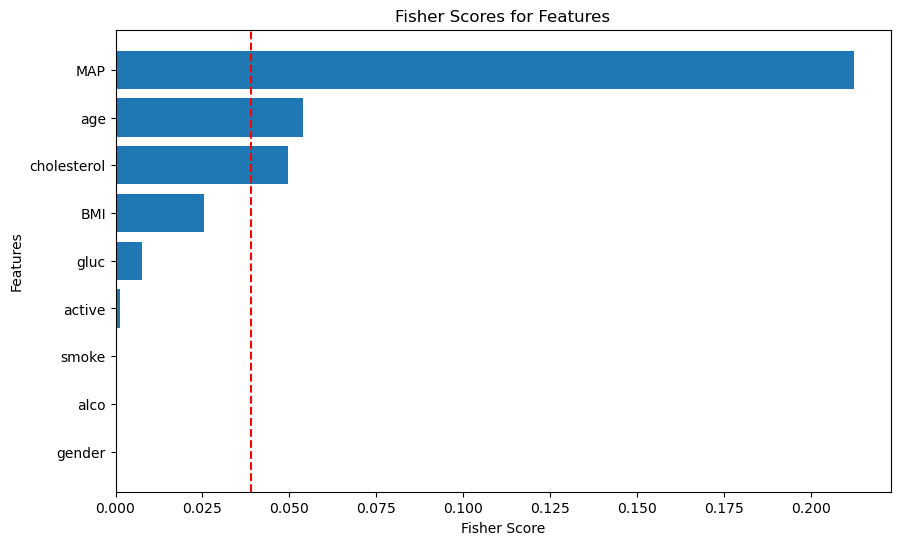

In [10]:
fisher_scores_sorted = sorted(fisher_scores.items(), key=lambda x: x[1])
features, scores = zip(*fisher_scores_sorted)
plt.figure(figsize=(10, 6))
plt.barh(features, scores)
plt.axvline(x=mean_fisher_score, color='r', linestyle='--', label='Mean Fisher Score')
plt.xlabel('Fisher Score')
plt.ylabel('Features')
plt.title('Fisher Scores for Features')

## Layer 2: Accuracy based Feature selection

In [11]:
def accuracy_based_feature_selection(mean_fisher_score, fisher_scores, selected_features, X_train, y_train, remaining_features_ratio=0.7):
    feature_accuracy_list = {}
    remaining_features_count = int(remaining_features_ratio * len(X_train.columns))
    initial_feature_count = len(selected_features)
    additional_features_needed = remaining_features_count - initial_feature_count
    final_feature_subset = selected_features.copy()
    sorted_fisher_scores = sorted(fisher_scores.items(), key=lambda x: x[1])
    X_train = X_train[:10000] # for speed
    y_train = y_train[:10000]

    for feature, score in sorted_fisher_scores:
        if feature not in selected_features:
            if score < mean_fisher_score:
                final_feature_subset.append(feature)
                selected_data = X_train[final_feature_subset]
                svm = SVC(kernel='rbf')
                accuracy = cross_val_score(svm, selected_data, y_train, cv=3).mean()
                feature_accuracy_list[feature] = accuracy
                final_feature_subset.remove(feature)

    sorted_accuracies = sorted(feature_accuracy_list.items(), key=lambda x: x[1], reverse=True)
    sorted_accuracies = [item for item in sorted_accuracies if item[0] not in selected_features]

    if additional_features_needed > 0:
        if len(sorted_accuracies) > additional_features_needed:
            cutoff_accuracy = sorted_accuracies[additional_features_needed-1][1]
            conditionally_selected_features = [feature for feature, acc in sorted_accuracies if acc >= cutoff_accuracy]

            if len(conditionally_selected_features) > additional_features_needed:
                tied_features = [feature for feature, acc in sorted_accuracies if acc == cutoff_accuracy]
                if len(tied_features) > 1:
                    tied_fisher_scores = {feature: fisher_scores[feature] for feature in tied_features}
                    highest_fisher_feature = max(tied_fisher_scores.items(), key=lambda x: x[1])[0]
                    conditionally_selected_features = [feature for feature in conditionally_selected_features if feature not in tied_features or feature == highest_fisher_feature]
                    conditionally_selected_features = conditionally_selected_features[:additional_features_needed]
        else:
            conditionally_selected_features = [feature for feature, acc in sorted_accuracies]
    else:
        conditionally_selected_features = []

    final_feature_subset.extend(conditionally_selected_features)
    return final_feature_subset, feature_accuracy_list

In [12]:
final_feature_subset, feature_accuracy_list = accuracy_based_feature_selection(mean_fisher_score, fisher_scores, selected_features, X_train, y_train)
print("Final selected features:", final_feature_subset)
print("Feature accuracy list:", feature_accuracy_list)

Final selected features: ['MAP', 'age', 'cholesterol', 'BMI', 'gender', 'gluc']
Feature accuracy list: {'gender': 0.7099998842115766, 'alco': 0.7098996642315702, 'smoke': 0.7096996442295701, 'active': 0.7088997742005754, 'gluc': 0.7098998742105764, 'BMI': 0.711299924233575}


In [13]:
X_train = X_train[final_feature_subset]

## PCA Feature Extarction

In [14]:

def run_pcafea(X_train, y_train, variance_threshold):
    scaler = StandardScaler()
    X_train_scaled_full = scaler.fit_transform(X_train)
    X_train_scaled, X_val_scaled, y_train, y_val = train_test_split(X_train_scaled_full, y_train)

    pca_full = PCA(n_components=None)
    pca_full.fit(X_train_scaled)
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

    candidate_k_values = np.where(cumulative_variance >= variance_threshold)[0] + 1

    best_k = -1
    best_validation_accuracy = -1.0

    if len(candidate_k_values) == 0:
        print("No candidate K values found, testing with all components")
        candidate_k_values = list(range(1, len(pca_full.explained_variance_ratio_) + 1))

    print("Candidate K values:", candidate_k_values)

    for k in candidate_k_values:
        pca_k = PCA(n_components=k)
        X_train_reduced_k = pca_k.fit_transform(X_train_scaled)
        X_val_reduced_k = pca_k.transform(X_val_scaled)
        svm_clf = SVC(kernel='rbf')
        svm_clf.fit(X_train_reduced_k, y_train)
        val_accuracy = svm_clf.score(X_val_reduced_k, y_val)
        print(f"K={k}: Validation Accuracy = {val_accuracy}")
        if val_accuracy > best_validation_accuracy:
            best_validation_accuracy = val_accuracy
            best_k = k

    print("Optimal number of components K:", best_k)
    pca_final = PCA(n_components=best_k)
    X_train_pca = pca_final.fit_transform(X_train_scaled_full)
    return X_train_pca, pca_final, scaler

In [16]:

X_train_pca, pca,scaler = run_pcafea(X_train,y_train, 0.70) #adjusted threshold because we use a different dataset

Candidate K values: [4 5 6]
K=4: Validation Accuracy = 0.7028237740980722
K=5: Validation Accuracy = 0.708823294136469
K=6: Validation Accuracy = 0.7105031597472202
Optimal number of components K: 6


In [17]:
X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])

# Classifier

## Hyperparameter Tunining and Training

In [18]:
model = SVC(kernel='rbf')
parameters = {'C': np.arange(0,1,0.1), 'gamma': np.arange(0,1,0.1)}
grid_search = GridSearchCV(model, parameters, cv=3, scoring='accuracy')
grid_search.fit(X_train_pca[:5000], y_train[:5000])

c:\Users\user1\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user1\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\user1\anaconda3\lib\site-packages\sklearn\svm\_base.py", line 180, in fit
    self._validate_params()
  File "c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py", line 581, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\user1\anaconda3\lib\site-packages\skle

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                         'gamma': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
             scoring='accuracy')

In [19]:
print("Best parameters from grid search:", grid_search.best_params_)
print("Best score from grid search:", grid_search.best_score_)
best_model = grid_search.best_estimator_
best_model.fit(X_train_pca, y_train)

Best parameters from grid search: {'C': 0.9, 'gamma': 0.5}
Best score from grid search: 0.7140011373475605


SVC(C=0.9, gamma=0.5)

## Evaluation

In [26]:
X_test = X_test[final_feature_subset]
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
y_pred = best_model.predict(X_test_pca)

c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [27]:
cm = confusion_matrix(y_test, y_pred)
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))




Recall: 0.7165367121507472
Precision: 0.7212230215827338
F1 score: 0.7188722294654498
Accuracy: 0.7240220782337413


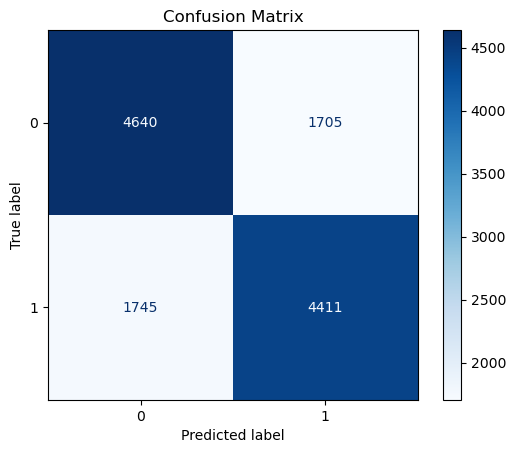

In [28]:
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
cm_display.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_train_pred = best_model.predict(X_train_pca)
y_train_pred_proba = best_model.decision_function(X_train_pca)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
roc_auc_train = auc(fpr_train, tpr_train)

y_test_pred_proba = best_model.decision_function(X_test_pca)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)
roc_auc_test = auc(fpr_test, tpr_test)






c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


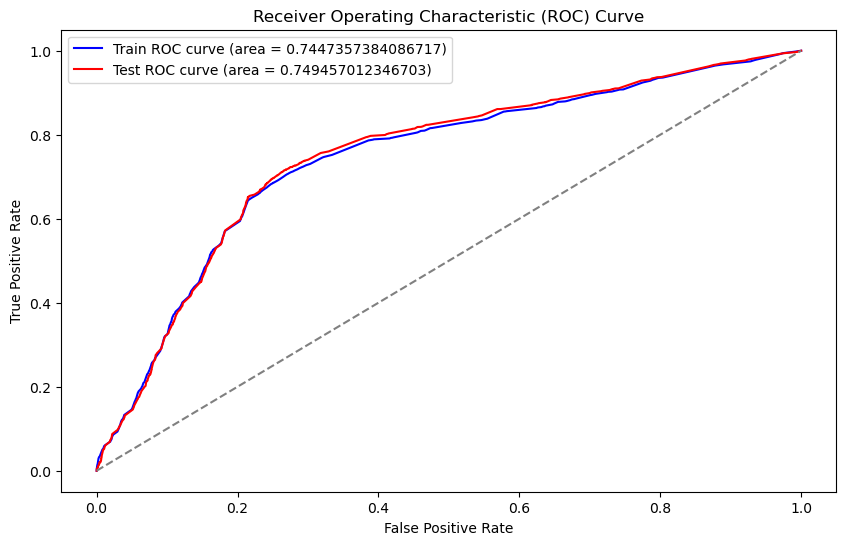

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, color='blue', label=f'Train ROC curve (area = {roc_auc_train})')
plt.plot(fpr_test, tpr_test, color='red', label=f'Test ROC curve (area = {roc_auc_test})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

## A quick test of the model without PCA given that the count of extracted components were equal to the original count of features

In [ ]:
#model without the pca step just the selected features, after scaling,
X_train = scaler.transform(X_train[final_feature_subset])
X_test = scaler.transform(X_test[final_feature_subset])
model_no_pca = SVC(kernel='rbf', C=0.7, gamma=0.5)
model_no_pca.fit(X_train, y_train)
y_pred_no_pca = model_no_pca.predict(X_test)



In [49]:
#  output teh accuracy, f1, precision, and recall only
print("Accuracy without PCA:", accuracy_score(y_test, y_pred_no_pca))
print("F1 score without PCA:", f1_score(y_test, y_pred_no_pca))
print("Precision without PCA:", precision_score(y_test, y_pred_no_pca))
print("Recall without PCA:", recall_score(y_test, y_pred_no_pca))

Accuracy without PCA: 0.7241020718342532
F1 score without PCA: 0.7182880013068692
Precision without PCA: 0.7223591260062429
Recall without PCA: 0.7142625081221572


# Explanation

## Princial Components Explanation

In [37]:
X_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.296345,-0.967906,-0.904005,0.256495,-0.652362,0.041005
1,-0.614518,-0.360238,-0.476868,-1.073737,0.071777,0.076655
2,-1.787738,0.569380,-1.562441,0.580797,0.041541,-0.162708
3,-0.247707,-0.510065,1.247852,2.478836,0.168279,0.289617
4,-0.873099,-0.164422,-0.690996,-0.444618,0.267949,0.059861


<Axes: >

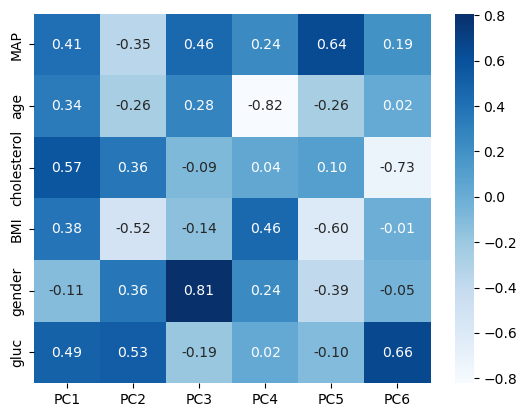

In [46]:
loadings = pca.components_.T
x_labels = [f'PC{i+1}' for i in range(6)]
sns.heatmap(loadings, cmap='Blues', annot=True, fmt='.2f', yticklabels=final_feature_subset, xticklabels=x_labels)

In [51]:
X_train_pca

,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.296345,-0.967906,-0.904005,0.256495,-0.652362,0.041005
1,-0.614518,-0.360238,-0.476868,-1.073737,0.071777,0.076655
2,-1.787738,0.569380,-1.562441,0.580797,0.041541,-0.162708
3,-0.247707,-0.510065,1.247852,2.478836,0.168279,0.289617
4,-0.873099,-0.164422,-0.690996,-0.444618,0.267949,0.059861
...,...,...,...,...,...,...
49996,-0.037765,-1.163722,-0.689876,-0.372624,-0.848534,0.057799
49997,-0.734200,-0.310775,-0.461938,0.417324,1.082873,0.232048
49998,1.062860,-0.822229,-0.603975,-0.943487,-0.890002,-1.001191
49999,2.649213,-0.841581,-0.916191,0.663552,-1.176407,0.313877


In [55]:
#treating each PC as a target feature with the input being the original features to get the effect of each feature on the PC
importances = {}
for i in range(pca.n_components_):
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, X_train_pca.iloc[:, i])  
    importances[f'PC{i+1}'] = rf.feature_importances_ 


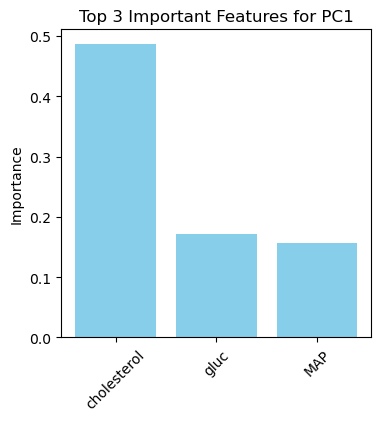

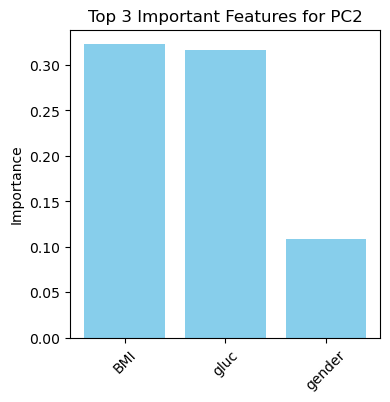

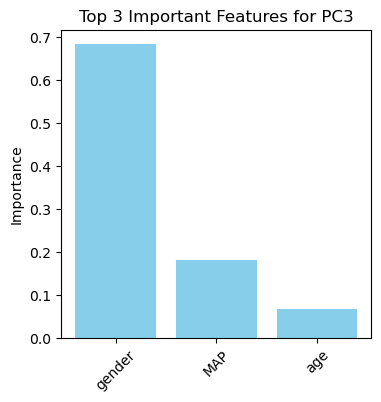

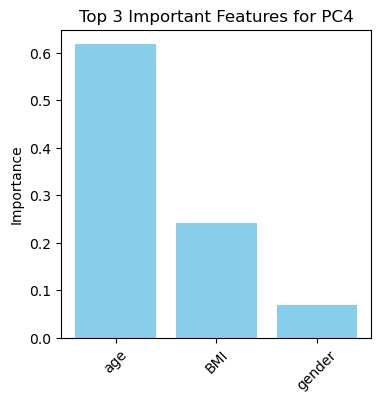

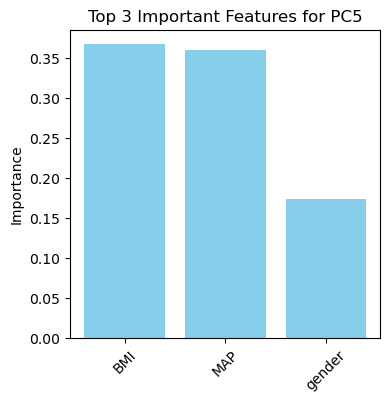

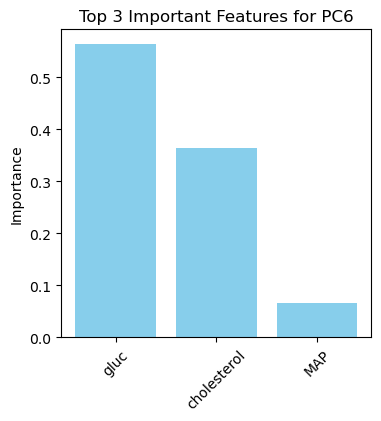

In [ ]:
for i in range(pca.n_components_):
    feature_importances = importances[f'PC{i+1}']
    sorted_indices = np.argsort(feature_importances)[::-1][:3]
    top_features = [final_feature_subset[j] for j in sorted_indices]
    top_importances = feature_importances[sorted_indices]

    plt.figure(figsize=(4, 4))
    plt.bar(top_features, top_importances, color='skyblue')
    plt.xticks(rotation=45)
    plt.ylabel('Importance')
    plt.title(f'Top 3 Important Features for {x_labels[i]}')
    plt.show()

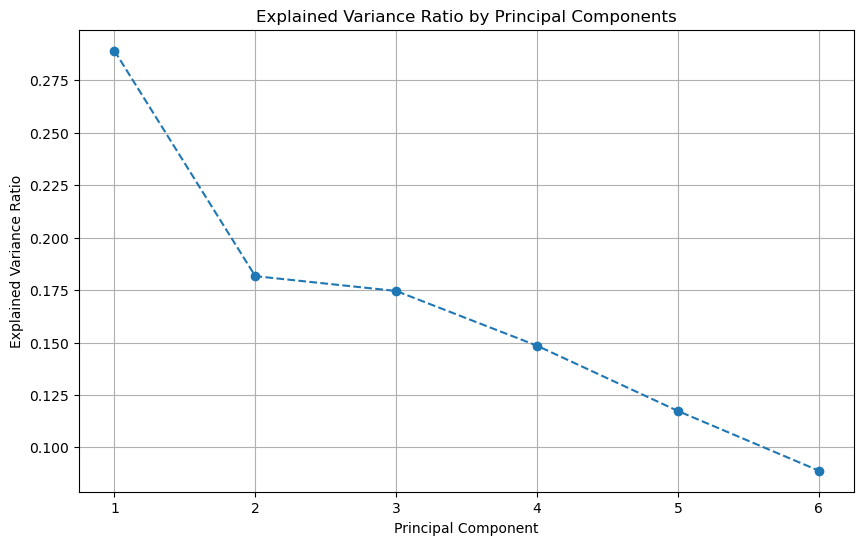

In [77]:
evr = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(evr) + 1), evr, marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(evr) + 1))
plt.grid()
plt.show()

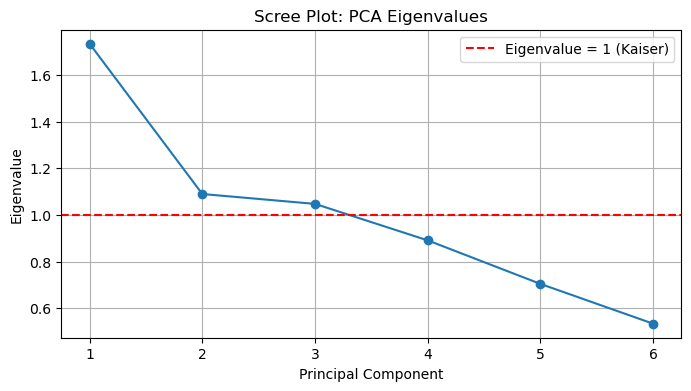

Components with eigenvalue > 1: [1, 2, 3]


In [78]:
# 1. Get raw eigenvalues
eigs = pca.explained_variance_

# 2. Plot eigenvalues with Kaiser cutoff
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigs) + 1),
         eigs, marker='o')
plt.axhline(y=1, color='r', linestyle='--',
            label='Eigenvalue = 1 (Kaiser)')
plt.title('Scree Plot: PCA Eigenvalues')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(eigs) + 1))
plt.legend()
plt.grid(True)
plt.show()

# 3. List PCs passing Kaiser
kaiser_pcs = [i+1 for i, val in enumerate(eigs) if val > 1]
print("Components with eigenvalue > 1:", kaiser_pcs)


## Model Explanation

### surrogate Decision Tree model

In [ ]:
#utilized later, could be ignored
X_train_pre_scaling,_,_,_ = train_test_split(X,y,test_size=0.2,random_state=42)
X_train_pre_scaling = X_train_pre_scaling[final_feature_subset]

In [111]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_pre_scaling, y_train_pred)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [112]:
dt.score(X_train_pre_scaling[final_feature_subset], y_train_pred)

0.9571208575828484

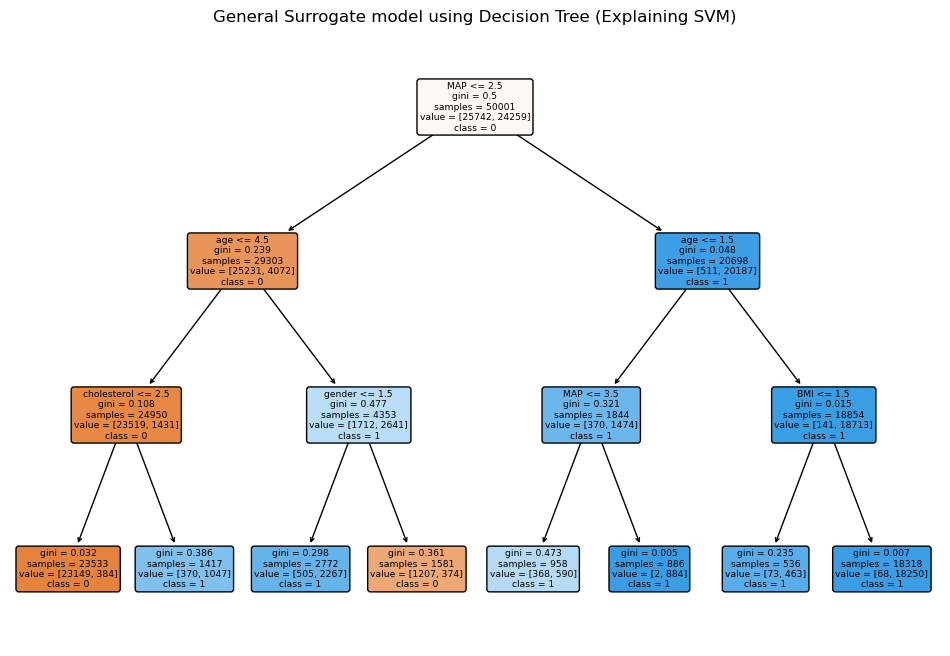

In [113]:
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=final_feature_subset, class_names=['0', '1'], filled=True, rounded=True)
plt.title("General Surrogate model using Decision Tree (Explaining SVM)")
plt.show()

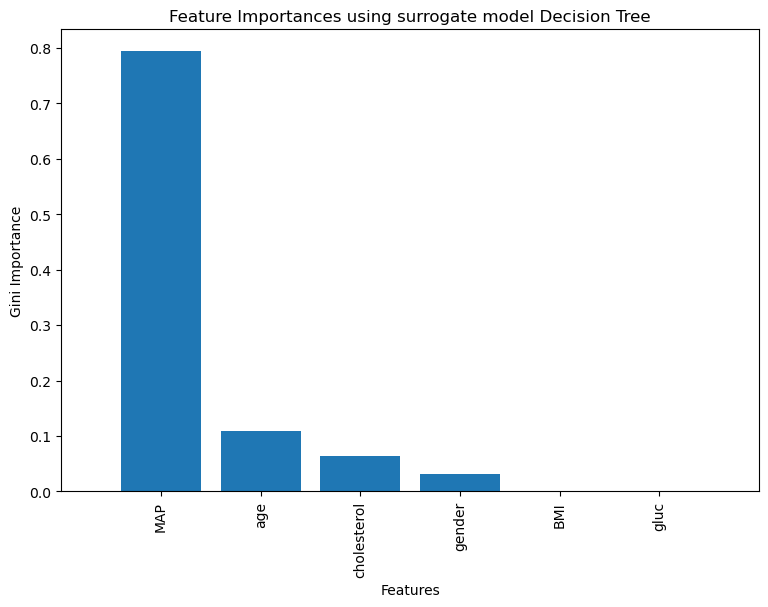

In [119]:
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [final_feature_subset[i] for i in indices]

plt.figure(figsize=(9, 6))
plt.title("Feature Importances using surrogate model Decision Tree")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), sorted_features, rotation=90)
plt.xlim([-1, len(importances)])
plt.ylabel("Gini Importance")
plt.xlabel("Features")
plt.show()

### SHAP mapped to original features

In [ ]:
def predict_fn(X):
    X_scaled = scaler.transform(X)
    X_pca = pca.transform(X_scaled)
    return best_model.predict(X_pca)

In [ ]:
X

In [180]:

explainer = shap.Explainer(predict_fn, X_train_pre_scaling[:200])
shap_values = explainer(X_train_pre_scaling[:200])

c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
ExactExplainer explainer:   2%|▏         | 3/200 [00:00<?, ?it/s]c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not ha

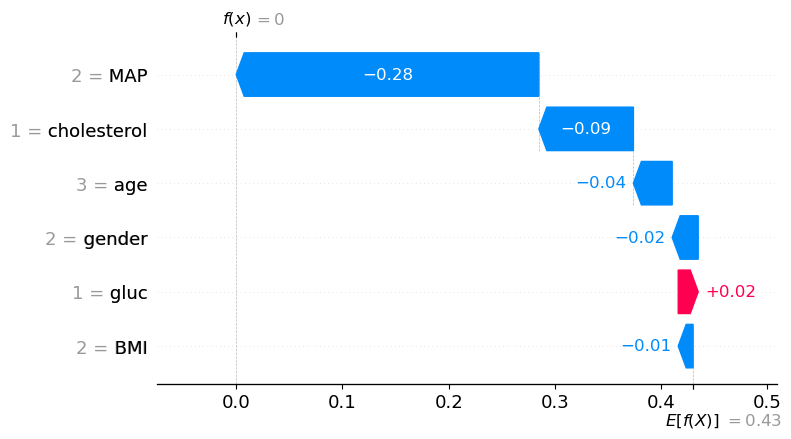

In [181]:
#shap values of original features
shap.plots.waterfall(shap_values[140])

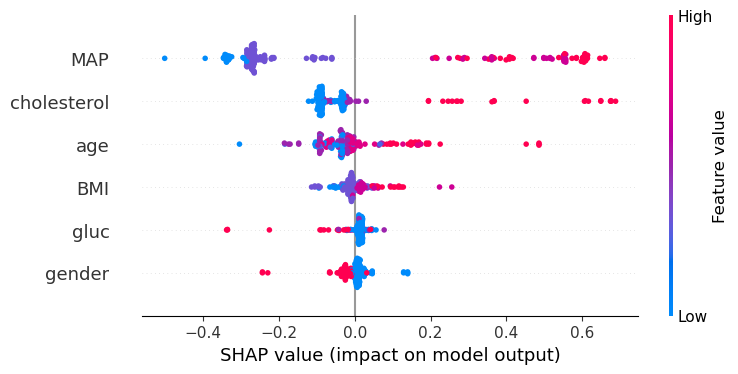

In [182]:
shap.plots.beeswarm(shap_values)

### LIME mapped to original Features

In [183]:
temp_svc = SVC(kernel='rbf', C=0.9, gamma=0.5, probability=True)
temp_svc.fit(X_train_pca, y_train)

SVC(C=0.9, gamma=0.5, probability=True)

In [185]:
def predict_fn_lime(X):
    X_scaled = scaler.transform(X)
    X_pca = pca.transform(X_scaled)
    return temp_svc.predict_proba(X_pca)

In [186]:
lime_explainer = LimeTabularExplainer(X_train_pre_scaling.values, feature_names=final_feature_subset, class_names=['0', '1'])

In [188]:
instance = lime_explainer.explain_instance(X_train_pre_scaling.values[140], predict_fn_lime)


c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\user1\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [189]:
instance.show_in_notebook()